In [27]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
with open('Essay3.txt', 'r', encoding='utf-8-sig') as f:
    text = f.read()

text = re.sub(r'\n+', ' ', text)
text = re.sub(r'\s{2,}', ' ', text).strip()

# Fixed regex - no spaces around |
pattern = re.compile(r'(?<=[.!?])\s+(?=[A-Z\[\("])|(?<=[.!?])$')
raw_sentences = pattern.split(text)

sentences = []
for s in raw_sentences:
    s = s.strip()
    if len(s) < 10:
        continue
    if not re.search(r'[.!?"\)]$', s) and len(s.split()) < 8:
        continue
    sentences.append(s)

df = pd.DataFrame(sentences, columns=['clean_text'])
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} column')

Shape: 785 rows x 1 column


In [29]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (785, 500)


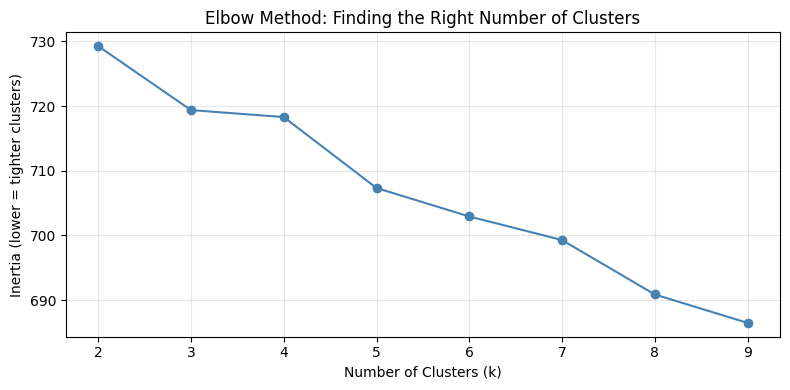

Look for the elbow — where the curve bends and flattens.
That k value is usually a good choice.



In [30]:
# ============================================================
# SECTION 1: ELBOW METHOD — find the right number of clusters
# ============================================================

inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")


In [31]:
# ============================================================
# SECTION 2: RUN K-MEANS with your chosen number of clusters
# ============================================================

NUM_CLUSTERS = 3  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_

In [32]:
# ============================================================
# SECTION 3: TOP WORDS PER CLUSTER
# ============================================================

print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print("Your job: give this cluster a name based on these words!")
    print("-" * 40)

TOP WORDS PER CLUSTER

Cluster 0 (691 documents)
Top words: moral, life, human, time, does, self, right, act, language, silence
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 1 (33 documents)
Top words: macbeth, guilt, ambition, lady, murder, culpability, duncan, banquo, hands, blood
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 2 (61 documents)
Top words: japan, nationalism, economic, japanese, cultural, national, pride, government, identity, nation
Your job: give this cluster a name based on these words!
----------------------------------------


In [33]:
# ============================================================
# SECTION 4: CLUSTER METRICS
# ============================================================

sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")


CLUSTER QUALITY METRICS

Silhouette Score: 0.029
  > 0.5 = strong clusters
  0.2-0.5 = reasonable clusters
  < 0.2 = weak or overlapping clusters

Davies-Bouldin Score: 3.891
  Closer to 0 = better separated clusters

Documents per cluster:
cluster
0    691
1     33
2     61
Name: count, dtype: int64
If one cluster has 90% of documents, try a different k



In [34]:
# ============================================================
# SECTION 5: SAMPLE DOCUMENTS FROM EACH CLUSTER
# ============================================================

print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['clean_text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

SAMPLE DOCUMENTS FROM EACH CLUSTER

--- Cluster 0 ---
  [1] Andrew Friedman Mr....
  [2] Jordan Karma of Words 2 March 2026 Choice’s Current When I chose to write this essay and continue, sentence by sentence, to move forward, it seems natural to imagine a self standing at a crossroads be...
  [3] Choice, in this familiar image, implies authorship....

--- Cluster 1 ---
  [1] Martin English III Period F 14 February 2024 The Fatality of Ambition Although Macbeth successfully seizes the throne in Shakespeare’s Macbeth, blood persistently revives his feelings of guilt, indica...
  [2] Predominant in the preliminary stages of the play, Macbeth’s adherence to his conscience constitutes his feelings of guilt and paranoia, a juxtaposition to the coldness of Lady Macbeth....
  [3] Contingent upon relieving his sense of culpability, Macbeth’s expression of his concerns only induces an insult from Lady Macbeth, claiming “[her] hands are of [Macbeth’s] color, but [she] shame / To ...

--- Cluster

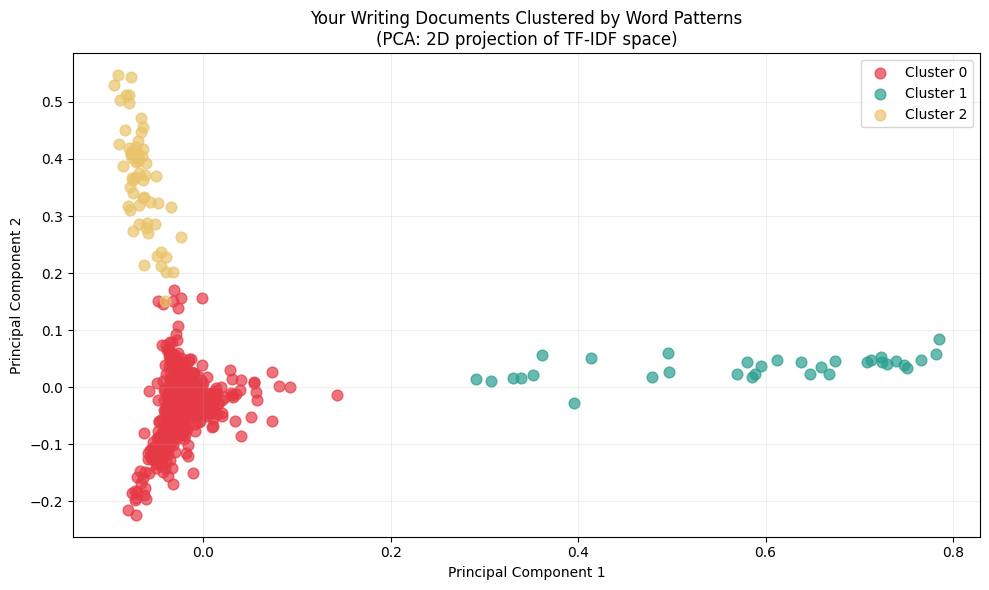

Each dot = one document. Dots close together = similar word patterns.



In [35]:
# ============================================================
# SECTION 6: PCA SCATTER PLOT — visualize clusters in 2D
# ============================================================

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#f4a261']

plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

In [36]:
# ============================================================
# SECTION 7: BUILD COSINE SIMILARITY MATRIX
# ============================================================

similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")

Similarity matrix shape: (785, 785)

Sample (first 4 documents vs first 4):
[[1.    0.    0.    0.   ]
 [0.    1.    0.111 0.   ]
 [0.    0.111 1.    0.   ]
 [0.    0.    0.    1.   ]]
Diagonal is always 1.0 — every document is identical to itself



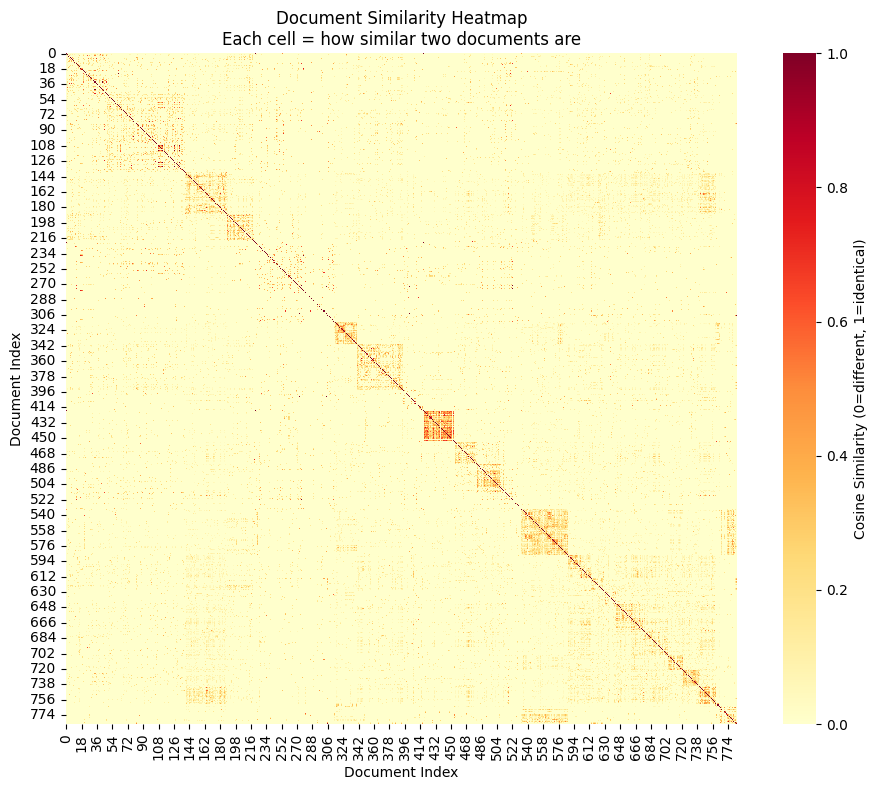

Bright red = very similar. Pale yellow = very different.



In [37]:
# ============================================================
# SECTION 8: SIMILARITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")

In [38]:
# ============================================================
# SECTION 9: MOST AND LEAST SIMILAR DOCUMENT PAIRS
# ============================================================

sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['clean_text'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['clean_text'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar?\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['clean_text'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['clean_text'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different?\n")

YOUR MOST SIMILAR DOCUMENT PAIR
Score: 1.000

Document 0:
  Andrew Friedman Mr....

Document 221:
  Andrew Friedman Mr....

Question: why do you think these two are so similar?

YOUR LEAST SIMILAR DOCUMENT PAIR
Score: 0.000

Document 0:
  Andrew Friedman Mr....

Document 1:
  Jordan Karma of Words 2 March 2026 Choice’s Current When I chose to write this essay and continue, sentence by sentence, to move forward, it seems natural to imagine a self standing at a crossroads between alternatives: to write or not to write, to think or to stop....

Question: what makes these two so different?



In [39]:
# ============================================================
# SECTION 10: FIND MOST SIMILAR DOCUMENTS TO A GIVEN DOCUMENT
# ============================================================

def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['clean_text'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['clean_text'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=0, similarity_matrix=similarity_matrix, df=df)

Source document [0]:
  Andrew Friedman Mr....

Top 5 most similar documents:

  [1] Similarity: 1.000
       Andrew Friedman Mr....

  [2] Similarity: 1.000
       Andrew Friedman Mr....

  [3] Similarity: 0.494
       I remember my first time on the water: the stroke radiated frustration as I continued to confuse even port and starboard, the head coach howling my name across the water. “Andrew!...

  [4] Similarity: 0.429
       From Pacifism to Pride: The Evolution of Japanese Nationalism and Excellence Andrew Friedman Forces That Shaped the Modern World Dr....

  [5] Similarity: 0.000
       He was frozen, head inattentively tilted, eyes tracing unfocused, indecipherable circles over the board—including everything but the move he had just made....



In [40]:
# ============================================================
# SECTION 11: SEARCH YOUR OWN WRITING WITH A NEW QUERY
# ============================================================

def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['clean_text'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="climate change and environmental policy",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

Query: 'climate change and environmental policy'

Most similar passages in your writing:

  [1] Similarity: 0.591
       Goodman, "Japan: Industrial Policy and the Economic Miracle," in From Industrial Policy to Innovation Strategy: Lessons from Japan, Europe, and the United States (n.p.: Center for Strategic and International Studies (CSIS), 2020), [Page #], JSTOR....

  [2] Similarity: 0.515
       Taken together, these considerations show that Dobbs cannot be redeemed as a morally neutral return of abortion policy to the states....

  [3] Similarity: 0.372
       [13] Leszek Buszynski, "Japan’s Security Policy in the Koizumi Era," Security Challenges 2, no. 3 (2006): JSTOR....

  [4] Similarity: 0.333
       [17] Gavan McCormack, "Japan's 'Positive Pacifism': Issues of Historical Memory in Contemporary Foreign Policy," The Brown Journal of World Affairs 20, no. 2 (2014): accessed May 19, 2024, http://www.jstor.org/stable/24590975....

  [5] Similarity: 0.263
       Through cultural 

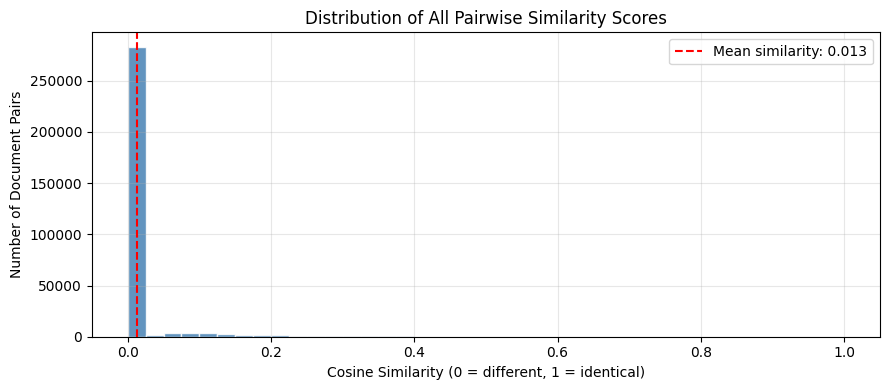

Average similarity across all pairs: 0.013
Most similar pair:  1.000
Least similar pair: 0.000

Reflection questions:
  - Is your writing more similar overall, or more varied?
  - Does this match your own sense of how diverse your topics are?
  - Which pair surprised you most?


In [41]:
# ============================================================
# SECTION 12: DISTRIBUTION OF ALL PAIRWISE SIMILARITY SCORES
# ============================================================

upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied?")
print("  - Does this match your own sense of how diverse your topics are?")
print("  - Which pair surprised you most?")

Is your writing more similar overall, or more varied?
- More varied. The mean similarity is only 0.013 (very close to 0), and the histogram shows the vast majority of sentence pairs cluster near zero. That means most sentences share very little vocabulary with each other.
Does this match your own sense of how diverse your topics are?
- The low similarity is not surpising because the essays cover a lot of groun If it covers a lot of ground, it makes sense.
"Which pair surprised you most?"
The most similar pair scoring 1.000 is the interesting one — that means two sentences were essentially identical in word usage. 